# Workshop: Transfer Learning with PyTorch

We will learn how to leverage the power of **Transfer Learning** to build high-performing image classifiers with very little data.

## Learning Objectives
1. **Understand Transfer Learning**: Why use a pre-trained model?
2. **Load a Pre-trained Model**: Using `torchvision.models` to load ResNet-18.
3. **Preprocess Data**: Preparing images exactly as the model expects.
4. **Inference Demo**: Classifying a random image (elephant or cat or plane etc.).
5. **Custom Training**: Modifying the network to classify our own classes of images of selected animals.

In [1]:
# Imports
# We import PyTorch, Torchvision, and standard plotting libraries.

import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torchvision import models, datasets

import matplotlib.pyplot as plt
import numpy as np

from PIL import Image
import urllib.request
import os

# %matplotlib inline

In [2]:
# Use GPU if available, otherwise CPU
device = 'cpu'
# device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cpu


## 1. Loading a Pre-trained Network

We will use **ResNet-18**, a powerful Convolutional Neural Network (CNN) trained on the **ImageNet** dataset (1.2 million images, 1000 classes).

> **Note**: `pretrained=True` downloads the weights learned on ImageNet.

In [4]:
# Load the pretrained ResNet-18 model
# model = models.resnet18(pretrained=True)

model = models.resnet18(weights="ResNet18_Weights.IMAGENET1K_V1") 
# IMAGENET1K_V1 is the default weights which are ImageNet1K with total 1000 classes.

# Set the model to evaluation mode (important for inference!)
# This freezes layers like Dropout and BatchNorm behavior.
model.eval()
model = model.to(device)

print("Model loaded successfully!")

Model loaded successfully!


### Check the classes available in the dataset


In [13]:
# Class labels 
categories = models.ResNet50_Weights.IMAGENET1K_V1.meta['categories']
print(len(categories))
print(categories)

1000
['tench', 'goldfish', 'great white shark', 'tiger shark', 'hammerhead', 'electric ray', 'stingray', 'cock', 'hen', 'ostrich', 'brambling', 'goldfinch', 'house finch', 'junco', 'indigo bunting', 'robin', 'bulbul', 'jay', 'magpie', 'chickadee', 'water ouzel', 'kite', 'bald eagle', 'vulture', 'great grey owl', 'European fire salamander', 'common newt', 'eft', 'spotted salamander', 'axolotl', 'bullfrog', 'tree frog', 'tailed frog', 'loggerhead', 'leatherback turtle', 'mud turtle', 'terrapin', 'box turtle', 'banded gecko', 'common iguana', 'American chameleon', 'whiptail', 'agama', 'frilled lizard', 'alligator lizard', 'Gila monster', 'green lizard', 'African chameleon', 'Komodo dragon', 'African crocodile', 'American alligator', 'triceratops', 'thunder snake', 'ringneck snake', 'hognose snake', 'green snake', 'king snake', 'garter snake', 'water snake', 'vine snake', 'night snake', 'boa constrictor', 'rock python', 'Indian cobra', 'green mamba', 'sea snake', 'horned viper', 'diamondba

## 2. Preprocessing: The Rules of the Game

Pre-trained models expect input images to be normalized in a specific way:
- **Resize**: Shortest side to 256 pixels.
- **CenterCrop**: Crop the center 224x224 patch.
- **ToTensor**: Convert image to PyTorch Tensor (C, H, W) with values [0, 1].
- **Normalize**: Subtract mean `[0.485, 0.456, 0.406]` and divide by std `[0.229, 0.224, 0.225]`.

In [4]:
# Define the standard ImageNet preprocessing pipeline
preprocess = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

## 3. Demo: Classifying an loaded image

Let's test the model on an image it has never seen before.

In [ ]:
# Download ImageNet class labels mapping (index to class name)

url_classes = "https://raw.githubusercontent.com/pytorch/hub/master/imagenet_classes.txt"
class_file = "./data/imagenet_classes.txt"
if not os.path.exists(class_file):
    urllib.request.urlretrieve(url_classes, class_file)

In [6]:
with open(class_file) as f:
    idx_to_class = [line.strip() for line in f.readlines()]

## Helper function to load and display an image

In [ ]:
def load_and_predict(image_url_or_path, model):
    """
    Load and predict
    Pass the image URL or path and the model to the function, and make predictions using a pre-trained model.
    """

    # Load image
    if image_url_or_path.startswith('http'):
        filename = './data/temp_image.jpg'
        urllib.request.urlretrieve(image_url_or_path, filename)
        img = Image.open(filename).convert('RGB')
    else:
        img = Image.open(image_url_or_path).convert('RGB')
    
    # Display image
    plt.imshow(img)
    plt.axis('off')
    plt.show()
    
    # Preprocess
    img_t = preprocess(img)
    batch_t = torch.unsqueeze(img_t, 0).to(device) # Add batch dimension

    # Predict
    with torch.no_grad():
        out = model(batch_t)
        probabilities = torch.nn.functional.softmax(out[0], dim=0)
    
    # Show Top-5
    top5_prob, top5_catid = torch.topk(probabilities, 5)
    print("\nTop-5 Predictions Obtained for the Image provided:")
    for i in range(top5_prob.size(0)):
        print(f"{idx_to_class[top5_catid[i]]:20} : {top5_prob[i].item()*100:.2f}%")

### Try it with an iamge from Web or local file!


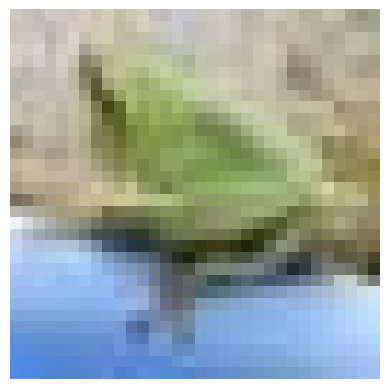


Top-5 Predictions:
platypus             : 10.99%
frilled lizard       : 6.51%
tailed frog          : 4.74%
vine snake           : 4.59%
green mamba          : 4.05%


In [ ]:
# image_url = "https://upload.wikimedia.org/wikipedia/commons/3/36/African_Elephant.jpg"
image_url = "D:\\Universities\\MSc-DLNN-Islington\\Codes\\temp_cifar.jpg"

load_and_predict(image_url, model) # Image and model

## 4. Transfer Learning: Custom Dataset

Why transfer learning?
Benefits:
- Transfer learning allows you to leverage pre-trained models that have already learned to recognize patterns in large datasets.
- It can help you build models with better performance, faster training, and less data.
- It can also help you build models with better generalization, as the pre-trained model has already learned to recognize patterns in a wide range of images.

Now, let's adapt this model to classify **animal vs objects** (or any two classes you have).

### Step 4.1: Prepare Data
We assume a folder structure like this:
```
data/
  train/
    animals/ (images...)
    objects/    (images...)
  val/
    animals/
    objects/
```
For this workshop, we'll create a dummy dataset structure or you can place your images there.

In [ ]:
# os.makedirs('data/train/animals', exist_ok=True)
# os.makedirs('data/train/objects', exist_ok=True)

data_dir = 'data'

# We use ImageFolder which expects the structure above
try:
    train_dataset = datasets.ImageFolder(os.path.join(data_dir, 'train'), transform=preprocess)
    val_dataset = datasets.ImageFolder(os.path.join(data_dir, 'val'), transform=preprocess)
    
    class_names = train_dataset.classes
    print(f"Classes found: {class_names}")
    
    train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=4, shuffle=True)
    val_loader = torch.utils.data.DataLoader(val_dataset, batch_size=4, shuffle=False)
except FileNotFoundError:
    print("Data directory not found! Please create 'data/train' and 'data/val' folders with class subfolders.")
    print("For now, we will skip the training execution block.")

### Step 4.2: Modify the Model
ResNet-18 outputs 1000 classes. 

We need to change the last layer (`fc`) to output `num_classes` (e.g., 2).

In [ ]:
# Freeze all layers

for param in model.parameters():
    param.requires_grad = False

# Replace the final fully connected layer
# model.fc.in_features gives us the input size (512 for ResNet18)

num_ftrs = model.fc.in_features
num_classes = 2 # Elephant vs Horse

# This new layer is created with requires_grad=True by default
model.fc = nn.Linear(num_ftrs, num_classes)

model = model.to(device)

print("Model modified for custom classes!")

### Step 4.3: Train (Fine-tune)
We only train the last layer.

In [ ]:
criterion = nn.CrossEntropyLoss()

# Optimize ONLY the parameters of the final layer
optimizer = optim.SGD(model.fc.parameters(), lr=0.001, momentum=0.9)

def train_model(model, criterion, optimizer, num_epochs=5):
    for epoch in range(num_epochs):
        print(f'Epoch {epoch+1}/{num_epochs}')
        print('-' * 10)

        # Each epoch has a training and validation phase
        for phase in ['train', 'val']:
            if phase == 'train':
                model.train()
                dataloader = train_loader
            else:
                model.eval()
                dataloader = val_loader

            running_loss = 0.0
            running_corrects = 0

            for inputs, labels in dataloader:
                inputs = inputs.to(device)
                labels = labels.to(device)

                optimizer.zero_grad()

                with torch.set_grad_enabled(phase == 'train'):
                    outputs = model(inputs)
                    _, preds = torch.max(outputs, 1)
                    loss = criterion(outputs, labels)

                    if phase == 'train':
                        loss.backward()
                        optimizer.step()

                running_loss += loss.item() * inputs.size(0)
                running_corrects += torch.sum(preds == labels.data)

            epoch_loss = running_loss / len(dataloader.dataset)
            epoch_acc = running_corrects.double() / len(dataloader.dataset)

            print(f'{phase} Loss: {epoch_loss:.4f} Acc: {epoch_acc:.4f}')

    return model

# Uncomment to run training if data is present
# model = train_model(model, criterion, optimizer, num_epochs=5)

## 5. Challenges & FAQs

We freeze the layers, To preserve the feature extractors learned from ImageNet. If we train everything from scratch with a small dataset, we might overfit or destroy those useful features.

What if my images are different sizes? 
- use `T.Resize(256)` and `T.CenterCrop(224)` in the transform pipeline. The model requires a fixed input size.